In [4]:
%cd ..

/home/user/Documentos/tec-mlops-project


In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [33]:
def evaluate_model(model, X_train, X_test, y_train, y_test, y_pred):
    y_t = np.square(y_test)
    y_p = np.square(y_pred)
    y_train2 = np.square(y_train)
    y_train_pred = np.square(model.predict(X_train))

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    r2_train = r2_score(y_train2, y_train_pred)
    r2 = r2_score(y_t, y_p)
    r2_adjusted = 1 - (1 - r2) * (
        (len(X_test) - 1) / (len(X_test) - X_test.shape[1] - 1)
    )
    
    plt.figure(figsize=(13,4))
    plt.plot((y_p)[:100])
    plt.plot((np.array(y_t)[:100]))
    plt.legend(["Predicted","Actual"])
    plt.title('Actual and Predicted Bike Count', fontsize=15)

    print("MSE :", mse)
    print("RMSE :", rmse)
    print("MAE :", mae)
    print("Train R2 :", r2_train)
    print("Test R2 :", r2)
    print("Adjusted R2 : ", r2_adjusted)

    model_score = [mse, rmse, mae, r2_train, r2, r2_adjusted]
    return model_score

In [34]:
X = pd.read_csv("./data/processed/X.csv")
y = pd.read_csv("./data/processed/y.csv")

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = np.sqrt(y)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Decision Tree Regressor

MSE : 38650882.69850403
RMSE : 6216.98340825388
MAE : 1696.8751438434983
Train R2 : 1.0
Test R2 : 0.9971614360858804
Adjusted R2 :  0.9971540653198021


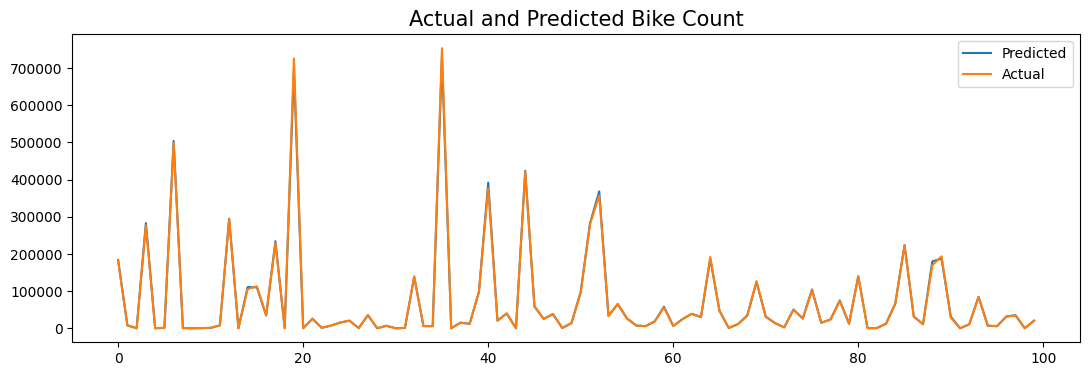

In [37]:
params={"max_depth":None}
model1 = DecisionTreeRegressor(**params)
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)
model1_eval = evaluate_model(model1, X_train, X_test, y_train, y_test, y_pred)

### KNeighbors Regressor

MSE : 280220374.68081754
RMSE : 16739.78418859746
MAE : 6945.210264672037
Train R2 : 0.9885881358201574
Test R2 : 0.9794203032884201
Adjusted R2 :  0.9793668649530467


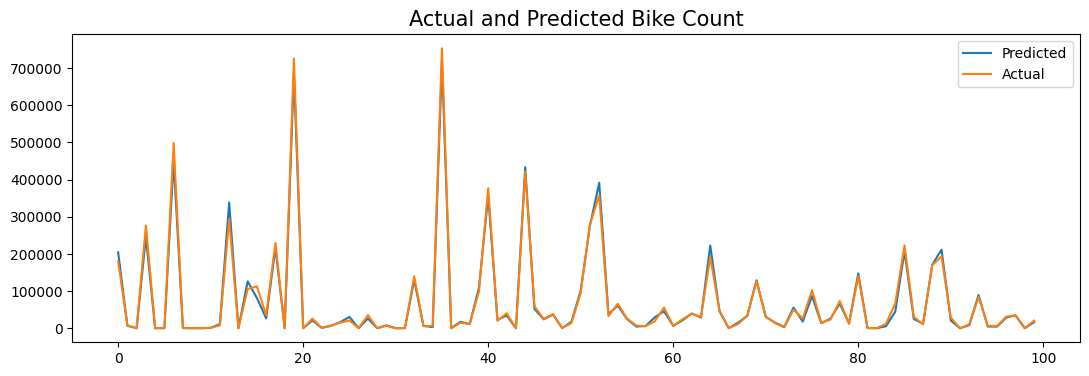

In [39]:
params={"n_neighbors":5}
model2 = KNeighborsRegressor(**params)
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)
model2_eval = evaluate_model(model2, X_train, X_test, y_train, y_test, y_pred)

### Support Vector Regressor

/home/user/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MSE : 1348523287.6861532
RMSE : 36722.24513406218
MAE : 20897.647365034954
Train R2 : 0.8993488583227612
Test R2 : 0.9009629463928361
Adjusted R2 :  0.900705781510417


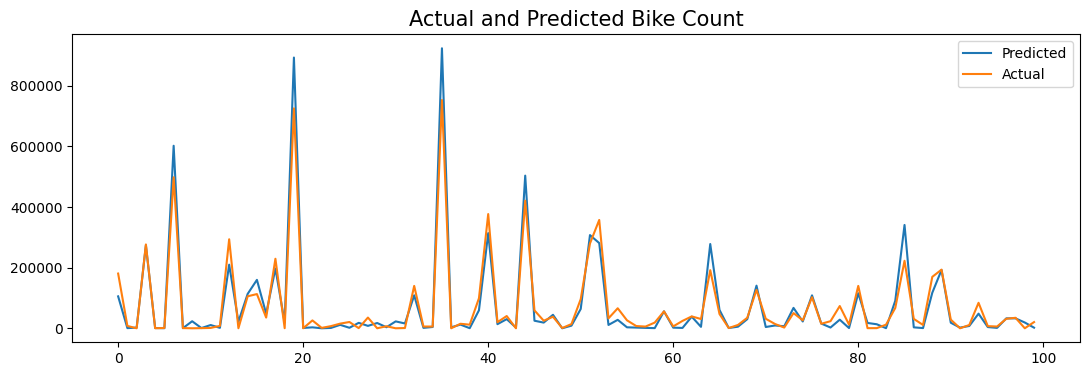

In [42]:
params={"kernel":"linear", "C":1.0}
model3 = SVR(**params)
model3.fit(X_train, y_train)
y_pred = model3.predict(X_test)
model3_eval = evaluate_model(model3, X_train, X_test, y_train, y_test, y_pred)

### Random Forest

/home/user/.local/lib/python3.10/site-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MSE : 12428878.782445379
RMSE : 3525.461499214731
MAE : 767.9337958573074
Train R2 : 0.9998484127389333
Test R2 : 0.9990872092862659
Adjusted R2 :  0.9990848390853359


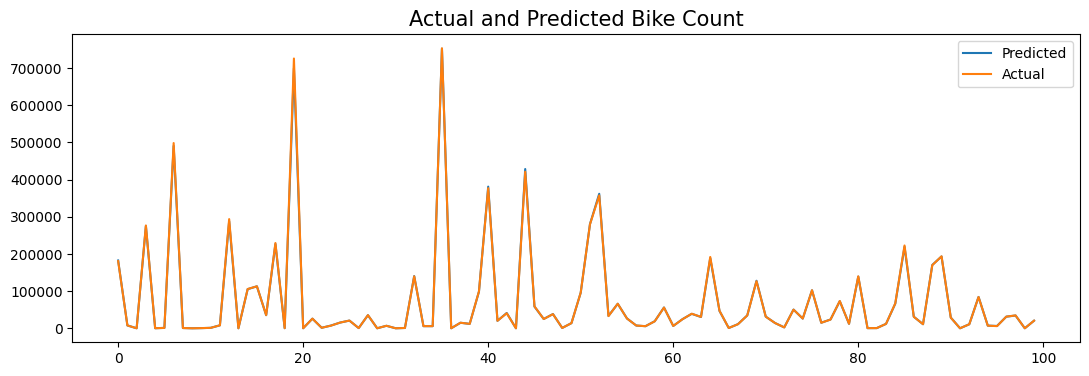

In [44]:
params={"n_estimators":100, "max_depth":None}
model4 = RandomForestRegressor(**params)
model4.fit(X_train, y_train)
y_pred = model4.predict(X_test)
model4_eval = evaluate_model(model4, X_train, X_test, y_train, y_test, y_pred)